In [1]:
import os
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
print("Installing dependencies...")
!pip install librosa soundfile -q
print("Installation complete!")

Installing dependencies...
Installation complete!


In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

print("All imports successful!")

All imports successful!


Configuration

In [4]:
AUDIO_CONFIG = {
    'sample_rate': 22050,
    'duration': 3,  # seconds
    'n_mfcc': 13,
    'test_size': 0.2,
    'val_size': 0.1,
    'random_state': 42
}

# Emotion mapping based on RAVDESS documentation
EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

print(f"Config loaded:")
print(f"Sample rate: {AUDIO_CONFIG['sample_rate']} Hz")
print(f"Duration: {AUDIO_CONFIG['duration']} seconds")
print(f"MFCCs: {AUDIO_CONFIG['n_mfcc']} coefficients")

Config loaded:
Sample rate: 22050 Hz
Duration: 3 seconds
MFCCs: 13 coefficients


Helper Functions

In [5]:
def parse_filename(filename):
    """
    Parse RAVDESS filename to extract metadata

    Filename format: Modality-VocalChannel-Emotion-Intensity-Statement-Repetition-Actor.wav
    Example: 03-01-06-01-02-01-12.wav

    Returns:
        dict: Metadata extracted from filename
    """
    parts = filename.replace('.wav', '').split('-')

    # Ensure we have all parts
    if len(parts) < 7:
        raise ValueError(f"Invalid filename format: {filename}")

    return {
        'modality': parts[0],
        'vocal_channel': parts[1],
        'emotion_code': parts[2],
        'emotion': EMOTION_MAP.get(parts[2], 'unknown'),
        'intensity': parts[3],
        'statement': parts[4],
        'repetition': parts[5],
        'actor': parts[6],
        'gender': 'female' if int(parts[6]) % 2 == 0 else 'male'
    }

def test_filename_parsing():
    """Test filename parsing"""
    print("\nTesting filename parsing...")

    test_file = "03-01-06-01-02-01-12.wav"
    metadata = parse_filename(test_file)

    print(f"   Test file: {test_file}")
    print(f"   Emotion: {metadata['emotion']}")
    print(f"   Gender: {metadata['gender']}")
    print(f"   Actor: {metadata['actor']}")
    print(f"   Statement: {metadata['statement']}")
    print(f"   Parsing successful!")

    return metadata

print("Helper functions loaded!")

Helper functions loaded!


Audio Feature Extraction

In [6]:
def extract_audio_features(file_path, sr=22050, duration=3):
    """
    Extract comprehensive audio features from an audio file

    Features extracted:
    - MFCCs (Mel-Frequency Cepstral Coefficients)
    - Chroma features
    - Mel spectrogram
    - Spectral contrast
    - Tonnetz
    - Zero crossing rate
    - RMS energy
    - Spectral centroid and rolloff

    Args:
        file_path: Path to audio file
        sr: Sample rate
        duration: Audio duration in seconds

    Returns:
        np.array: Feature vector
    """
    try:
        # Load audio file
        audio, sample_rate = librosa.load(file_path, sr=sr, duration=duration)

        # Initialize features dictionary
        features = {}

        # 1. MFCCs (Mel-Frequency Cepstral Coefficients)
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
        features['mfcc_mean'] = np.mean(mfccs, axis=1)
        features['mfcc_std'] = np.std(mfccs, axis=1)

        # 2. Chroma features (pitch class representation)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
        features['chroma_mean'] = np.mean(chroma, axis=1)
        features['chroma_std'] = np.std(chroma, axis=1)

        # 3. Mel spectrogram
        mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
        features['mel_mean'] = np.mean(mel, axis=1)
        features['mel_std'] = np.std(mel, axis=1)

        # 4. Spectral contrast
        contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)
        features['contrast_mean'] = np.mean(contrast, axis=1)
        features['contrast_std'] = np.std(contrast, axis=1)

        # 5. Tonnetz (tonal centroid features)
        tonnetz = librosa.feature.tonnetz(y=audio, sr=sample_rate)
        features['tonnetz_mean'] = np.mean(tonnetz, axis=1)
        features['tonnetz_std'] = np.std(tonnetz, axis=1)

        # 6. Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(audio)
        features['zcr_mean'] = np.mean(zcr)
        features['zcr_std'] = np.std(zcr)

        # 7. RMS Energy
        rms = librosa.feature.rms(y=audio)
        features['rms_mean'] = np.mean(rms)
        features['rms_std'] = np.std(rms)

        # 8. Spectral centroid
        spectral_centroids = librosa.feature.spectral_centroid(y=audio, sr=sample_rate)
        features['spectral_centroid_mean'] = np.mean(spectral_centroids)
        features['spectral_centroid_std'] = np.std(spectral_centroids)

        # 9. Spectral rolloff
        spectral_rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sample_rate)
        features['spectral_rolloff_mean'] = np.mean(spectral_rolloff)
        features['spectral_rolloff_std'] = np.std(spectral_rolloff)

        # Flatten all features into a single vector
        feature_vector = []
        for key in sorted(features.keys()):
            if isinstance(features[key], np.ndarray):
                feature_vector.extend(features[key])
            else:
                feature_vector.append(features[key])

        return np.array(feature_vector)

    except Exception as e:
        print(f"Error processing {file_path}: {str(e)}")
        return None

print("Feature extraction functions loaded!")

Feature extraction functions loaded!


Dataset Loading

In [7]:
def load_ravdess_dataset(data_path):
    """
    Load all audio files from RAVDESS dataset and extract features

    Args:
        data_path: Path to RAVDESS dataset directory

    Returns:
        pd.DataFrame: Dataset with features and metadata
    """
    data = []
    sr = AUDIO_CONFIG['sample_rate']
    duration = AUDIO_CONFIG['duration']

    print(f"\nScanning dataset directory: {data_path}")

    # Count total files first
    total_files = 0
    for root, dirs, files in os.walk(data_path):
        total_files += sum(1 for f in files if f.endswith('.wav'))

    print(f"   Found {total_files} audio files")

    # Process files
    print(f"\nProcessing audio files...")
    processed = 0

    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.endswith('.wav'):
                file_path = os.path.join(root, file)

                # Parse metadata from filename
                metadata = parse_filename(file)

                # Extract audio features
                features = extract_audio_features(file_path, sr=sr, duration=duration)

                if features is not None:
                    data.append({
                        'filename': file,
                        'filepath': file_path,
                        'features': features,
                        'emotion': metadata['emotion'],
                        'emotion_code': metadata['emotion_code'],
                        'intensity': metadata['intensity'],
                        'statement': metadata['statement'],
                        'gender': metadata['gender'],
                        'actor': metadata['actor']
                    })

                    processed += 1

                    # Progress indicator
                    if processed % 100 == 0:
                        print(f"   Processed {processed}/{total_files} files...")

    print(f"\nSuccessfully processed {len(data)} audio files")

    return pd.DataFrame(data)

print("Dataset loading functions loaded!")

Dataset loading functions loaded!


Data Preparation

In [8]:
def prepare_audio_data(df, test_size=0.2, val_size=0.1):
    """
    Prepare data for training: split and normalize

    Args:
        df: DataFrame with features and labels
        test_size: Test set proportion
        val_size: Validation set proportion (from remaining data)

    Returns:
        dict: Dictionary with train/val/test splits
    """
    print("\nPreparing data for training...")

    # Extract features and labels
    X = np.array(df['features'].tolist())
    y = df['emotion'].values

    print(f"   Feature shape: {X.shape}")
    print(f"   Labels: {len(y)}")

    # Initialize label encoder
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y)

    print(f"   Emotion classes: {label_encoder.classes_}")

    # Split data: train, validation, test
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y_encoded,
        test_size=test_size,
        random_state=AUDIO_CONFIG['random_state'],
        stratify=y_encoded
    )

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val,
        test_size=val_size/(1-test_size),
        random_state=AUDIO_CONFIG['random_state'],
        stratify=y_train_val
    )

    # Initialize scaler
    scaler = StandardScaler()

    # Normalize features
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    X_test = scaler.transform(X_test)

    print(f"\n   Dataset split:")
    print(f"   ✓ Training set: {X_train.shape[0]} samples")
    print(f"   ✓ Validation set: {X_val.shape[0]} samples")
    print(f"   ✓ Test set: {X_test.shape[0]} samples")
    print(f"   ✓ Feature dimension: {X_train.shape[1]}")

    return {
        'X_train': X_train,
        'X_val': X_val,
        'X_test': X_test,
        'y_train': y_train,
        'y_val': y_val,
        'y_test': y_test,
        'label_encoder': label_encoder,
        'scaler': scaler,
        'emotion_classes': label_encoder.classes_
    }

print("Data preparation functions loaded!")

Data preparation functions loaded!


Visualization

In [9]:

def visualize_audio_dataset(df, output_dir):
    """
    Visualize the distribution of emotions and other metadata in the dataset
    """
    print("\nCreating visualizations...")

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    plt.figure(figsize=(15, 10))

    # 1. Emotion distribution
    plt.subplot(2, 3, 1)
    emotion_counts = df['emotion'].value_counts()
    emotion_counts.plot(kind='bar', color='skyblue')
    plt.title('Emotion Distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Emotion')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    # 2. Gender distribution per emotion
    plt.subplot(2, 3, 2)
    gender_emotion = pd.crosstab(df['emotion'], df['gender'])
    gender_emotion.plot(kind='bar', stacked=False, ax=plt.gca())
    plt.title('Gender Distribution per Emotion', fontsize=12, fontweight='bold')
    plt.xlabel('Emotion')
    plt.ylabel('Count')
    plt.legend(title='Gender')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    # 3. Intensity distribution
    plt.subplot(2, 3, 3)
    intensity_counts = df['intensity'].value_counts()
    intensity_labels = {
        '01': 'Normal',
        '02': 'Strong'
    }
    intensity_counts.index = [intensity_labels.get(str(i), str(i)) for i in intensity_counts.index]
    intensity_counts.plot(kind='bar', color='coral')
    plt.title('Intensity Distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Intensity')
    plt.ylabel('Count')
    plt.xticks(rotation=0)
    plt.grid(axis='y', alpha=0.3)

    # 4. Actors per gender
    plt.subplot(2, 3, 4)
    gender_counts = df['gender'].value_counts()
    plt.pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['lightblue', 'lightpink'])
    plt.title('Gender Distribution', fontsize=12, fontweight='bold')

    # 5. Emotion by intensity
    plt.subplot(2, 3, 5)
    emotion_intensity = pd.crosstab(df['emotion'], df['intensity'])
    emotion_intensity.columns = [intensity_labels.get(str(i), str(i)) for i in emotion_intensity.columns]
    emotion_intensity.plot(kind='bar', stacked=True, ax=plt.gca(), colormap='viridis')
    plt.title('Emotion by Intensity', fontsize=12, fontweight='bold')
    plt.xlabel('Emotion')
    plt.ylabel('Count')
    plt.legend(title='Intensity')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    # 6. Statement distribution
    plt.subplot(2, 3, 6)
    statement_counts = df['statement'].value_counts()
    statement_labels = {
        '01': 'Kids talking',
        '02': 'Dogs sitting'
    }
    statement_counts.index = [statement_labels.get(str(i), str(i)) for i in statement_counts.index]
    statement_counts.plot(kind='bar', color='lightgreen')
    plt.title('Statement Distribution', fontsize=12, fontweight='bold')
    plt.xlabel('Statement')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()

    # Save figure
    viz_path = os.path.join(output_dir, 'audio_dataset_visualization.png')
    plt.savefig(viz_path, dpi=300, bbox_inches='tight')
    print(f"   ✓ Saved visualization to: {viz_path}")
    plt.show()

    # Print statistics
    print(f"\n📈 Dataset Statistics:")
    print(f"   Total samples: {len(df)}")
    print(f"\n   Emotion distribution:")
    for emotion, count in emotion_counts.items():
        print(f"      {emotion}: {count}")
    print(f"\n   Gender distribution:")
    for gender, count in gender_counts.items():
        print(f"      {gender}: {count}")
    print(f"\n   Feature vector size: {len(df['features'].iloc[0])}")

print("Visualization functions loaded!")

Visualization functions loaded!


Save Functions

In [10]:
def save_preprocessed_audio_data(data_dict, df, output_dir):
    """
    Save all preprocessed audio data and preprocessing objects
    """
    os.makedirs(output_dir, exist_ok=True)

    print(f"\nSaving preprocessed data to: {output_dir}")

    # Save data splits
    np.save(os.path.join(output_dir, 'X_train_audio.npy'), data_dict['X_train'])
    np.save(os.path.join(output_dir, 'X_val_audio.npy'), data_dict['X_val'])
    np.save(os.path.join(output_dir, 'X_test_audio.npy'), data_dict['X_test'])
    np.save(os.path.join(output_dir, 'y_train_audio.npy'), data_dict['y_train'])
    np.save(os.path.join(output_dir, 'y_val_audio.npy'), data_dict['y_val'])
    np.save(os.path.join(output_dir, 'y_test_audio.npy'), data_dict['y_test'])
    print("   X_train_audio.npy")
    print("   X_val_audio.npy")
    print("   X_test_audio.npy")
    print("   y_train_audio.npy")
    print("   y_val_audio.npy")
    print("   y_test_audio.npy")

    # Save preprocessing objects
    with open(os.path.join(output_dir, 'label_encoder_audio.pkl'), 'wb') as f:
        pickle.dump(data_dict['label_encoder'], f)
    print("label_encoder_audio.pkl")

    with open(os.path.join(output_dir, 'scaler_audio.pkl'), 'wb') as f:
        pickle.dump(data_dict['scaler'], f)
    print("scaler_audio.pkl")

    # Save audio metadata
    audio_metadata = {
        'total_samples': len(df),
        'train_samples': len(data_dict['X_train']),
        'val_samples': len(data_dict['X_val']),
        'test_samples': len(data_dict['X_test']),
        'feature_dimension': data_dict['X_train'].shape[1],
        'num_emotions': len(data_dict['emotion_classes']),
        'emotion_classes': data_dict['emotion_classes'].tolist(),
        'emotion_distribution': df['emotion'].value_counts().to_dict(),
        'gender_distribution': df['gender'].value_counts().to_dict(),
        'config': AUDIO_CONFIG
    }

    with open(os.path.join(output_dir, 'audio_metadata.json'), 'w') as f:
        json.dump(audio_metadata, f, indent=2)
    print("audio_metadata.json")

    # Save DataFrame as CSV
    df_to_save = df.drop('features', axis=1)  # Remove feature arrays
    df_to_save.to_csv(os.path.join(output_dir, 'audio_dataset_info.csv'), index=False)
    print("audio_dataset_info.csv")

    print(f"\nAll audio data saved successfully!")

print("Save functions loaded!")

Save functions loaded!


Main Execution

In [11]:

def main_audio_preprocessing(data_path, output_dir):
    """
    Main preprocessing pipeline for RAVDESS audio dataset
    """

    print("="*70)
    print("RAVDESS AUDIO PREPROCESSING FOR EMOTION RECOGNITION")
    print("="*70)

    # Test filename parsing
    test_filename_parsing()

    # Load dataset
    print("\n" + "="*70)
    print("LOADING DATASET")
    print("="*70)
    df = load_ravdess_dataset(data_path)

    if len(df) == 0:
        print("\nNo audio files found! Please check the data path.")
        return None

    # Visualize data distribution
    print("\n" + "="*70)
    print("VISUALIZING DATA")
    print("="*70)
    visualize_audio_dataset(df, output_dir)

    # Prepare data for training
    print("\n" + "="*70)
    print("PREPARING DATA")
    print("="*70)
    data_dict = prepare_audio_data(df)

    # Save preprocessed data
    print("\n" + "="*70)
    print("SAVING DATA")
    print("="*70)
    save_preprocessed_audio_data(data_dict, df, output_dir)

    # Final summary
    print("\n" + "="*70)
    print("FINAL SUMMARY")
    print("="*70)
    print(f"   ✓ Total audio files processed: {len(df)}")
    print(f"   ✓ Training samples: {len(data_dict['X_train'])}")
    print(f"   ✓ Validation samples: {len(data_dict['X_val'])}")
    print(f"   ✓ Test samples: {len(data_dict['X_test'])}")
    print(f"   ✓ Feature dimension: {data_dict['X_train'].shape[1]}")
    print(f"   ✓ Emotion classes: {len(data_dict['emotion_classes'])}")
    print(f"   ✓ Emotions: {', '.join(data_dict['emotion_classes'])}")

    print("\n" + "="*70)
    print("AUDIO PREPROCESSING COMPLETE!")
    print("="*70)
    print("\n📝 Next steps:")
    print("   1. ✓ Audio preprocessing DONE")
    print("   2. ✓ Text preprocessing DONE (already completed)")
    print("   3. → Build multimodal fusion model")
    print("   4. → Train on combined text + audio features")

    return df, data_dict

print("Main functions loaded!")

Main functions loaded!


Run Everything!

CHECKING PATH
Data path: /content/drive/MyDrive/threec/audio dataset/audio_speech_actors_01-24/
Output path: /content/drive/MyDrive/threec/processed_audio

✓ Path exists!
✓ Found approximately 1440 audio files

STARTING AUDIO PREPROCESSING
RAVDESS AUDIO PREPROCESSING FOR EMOTION RECOGNITION

Testing filename parsing...
   Test file: 03-01-06-01-02-01-12.wav
   Emotion: fearful
   Gender: female
   Actor: 12
   Statement: 02
   Parsing successful!

LOADING DATASET

Scanning dataset directory: /content/drive/MyDrive/threec/audio dataset/audio_speech_actors_01-24/
   Found 1440 audio files

Processing audio files...
   Processed 100/1440 files...
   Processed 200/1440 files...
   Processed 300/1440 files...
   Processed 400/1440 files...
   Processed 500/1440 files...
   Processed 600/1440 files...
   Processed 700/1440 files...
   Processed 800/1440 files...
   Processed 900/1440 files...
   Processed 1000/1440 files...
   Processed 1100/1440 files...
   Processed 1200/1440 files...
   P

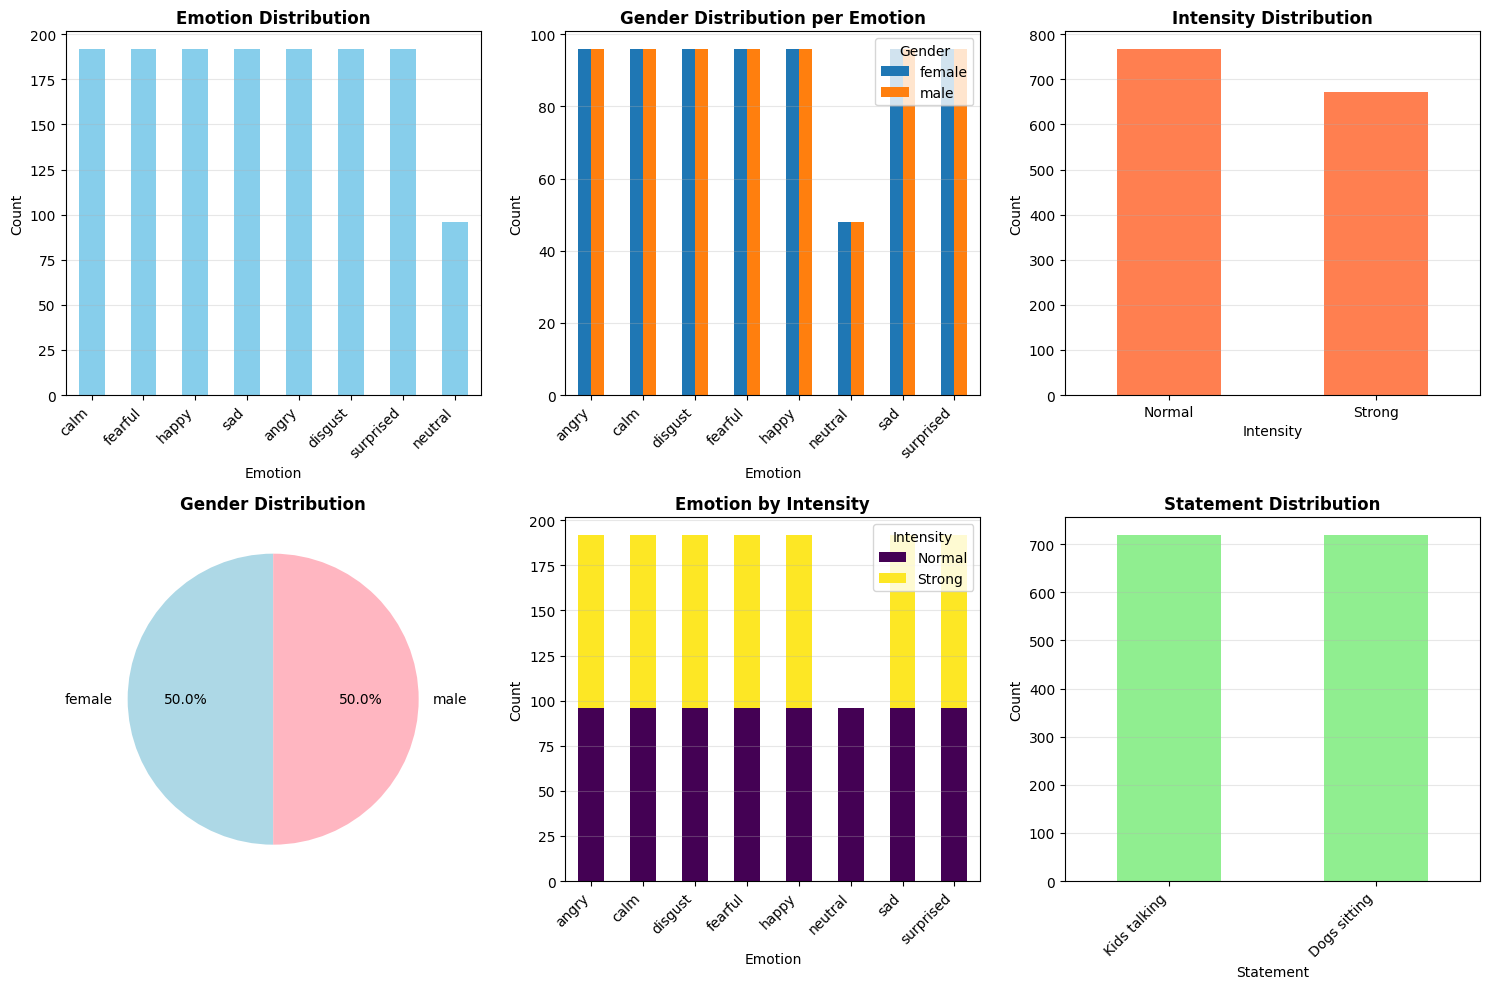


📈 Dataset Statistics:
   Total samples: 1440

   Emotion distribution:
      calm: 192
      fearful: 192
      happy: 192
      sad: 192
      angry: 192
      disgust: 192
      surprised: 192
      neutral: 96

   Gender distribution:
      female: 720
      male: 720

   Feature vector size: 340

PREPARING DATA

Preparing data for training...
   Feature shape: (1440, 340)
   Labels: 1440
   Emotion classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']

   Dataset split:
   ✓ Training set: 1008 samples
   ✓ Validation set: 144 samples
   ✓ Test set: 288 samples
   ✓ Feature dimension: 340

SAVING DATA

Saving preprocessed data to: /content/drive/MyDrive/threec/processed_audio
   X_train_audio.npy
   X_val_audio.npy
   X_test_audio.npy
   y_train_audio.npy
   y_val_audio.npy
   y_test_audio.npy
label_encoder_audio.pkl
scaler_audio.pkl
audio_metadata.json
audio_dataset_info.csv

All audio data saved successfully!

FINAL SUMMARY
   ✓ Total audio files proce

In [12]:
data_path = "/content/drive/MyDrive/threec/audio dataset/audio_speech_actors_01-24/"
output_dir = "/content/drive/MyDrive/threec/processed_audio"

print("="*70)
print("CHECKING PATH")
print("="*70)
print(f"Data path: {data_path}")
print(f"Output path: {output_dir}\n")

# Check if path exists
if not os.path.exists(data_path):
    print("Path does not exist!")
    print("\nIf your path is different, update the 'data_path' variable above.")
    print("   Your structure should be: .../audio_speech_actors_01-24/Actor_XX/*.wav")
else:
    # Count files quickly
    total_files = 0
    for root, dirs, files in os.walk(data_path):
        total_files += sum(1 for f in files if f.endswith('.wav'))

    if total_files == 0:
        print("No .wav files found in this directory!")
        print("\nCheck if the audio files are in the Actor_XX subfolders.")
    else:
        print(f"✓ Path exists!")
        print(f"✓ Found approximately {total_files} audio files\n")

        # Run the complete audio preprocessing pipeline
        print("="*70)
        print("STARTING AUDIO PREPROCESSING")
        print("="*70)

        result = main_audio_preprocessing(data_path, output_dir)

        if result is not None:
            df, data_dict = result
            print(f"\nSUCCESS! Processed {len(df)} audio files")
            print(f"Output saved to: {output_dir}")
        else:
            print("\nPreprocessing failed!")

Quick Verification

In [13]:

if 'df' in locals() and df is not None:
    print("\n" + "="*70)
    print("VERIFYING SAVED DATA")
    print("="*70)

    # Load and verify arrays
    X_train = np.load(os.path.join(output_dir, 'X_train_audio.npy'))
    print(f"✓ Loaded X_train_audio.npy: shape {X_train.shape}")

    X_val = np.load(os.path.join(output_dir, 'X_val_audio.npy'))
    print(f"✓ Loaded X_val_audio.npy: shape {X_val.shape}")

    X_test = np.load(os.path.join(output_dir, 'X_test_audio.npy'))
    print(f"✓ Loaded X_test_audio.npy: shape {X_test.shape}")

    # Load metadata
    with open(os.path.join(output_dir, 'audio_metadata.json'), 'r') as f:
        metadata = json.load(f)
    print(f"✓ Loaded audio_metadata.json")

    # Load label encoder
    with open(os.path.join(output_dir, 'label_encoder_audio.pkl'), 'rb') as f:
        label_encoder = pickle.load(f)
    print(f"✓ Loaded label_encoder_audio.pkl")

    # Sample check
    print(f"\nSample metadata:")
    print(f"   Total samples: {metadata['total_samples']}")
    print(f"   Emotion classes: {metadata['emotion_classes']}")
    print(f"   Feature dimension: {metadata['feature_dimension']}")
    print(f"   Sample rate: {metadata['config']['sample_rate']} Hz")

    print("\nAll audio files verified and ready for model training!")
    print("\nNow you can combine with text data for multimodal emotion recognition!")


VERIFYING SAVED DATA
✓ Loaded X_train_audio.npy: shape (1008, 340)
✓ Loaded X_val_audio.npy: shape (144, 340)
✓ Loaded X_test_audio.npy: shape (288, 340)
✓ Loaded audio_metadata.json
✓ Loaded label_encoder_audio.pkl

Sample metadata:
   Total samples: 1440
   Emotion classes: ['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
   Feature dimension: 340
   Sample rate: 22050 Hz

All audio files verified and ready for model training!

Now you can combine with text data for multimodal emotion recognition!
